# ZNO Outcomes: Analysis & ML Prediction (2016–2021)

Notebook goal:
End-to-end, leakage-aware modeling of Ukrainian standardized tests (ZNO) across 2016–2021.

The pipeline ingests multi-year raw files, harmonizes schema, enforces a temporal split
(train: 2016–2020 → test: 2021), trains baselines and tree ensembles with early stopping,
then produces diagnostics, fairness slices with CI, feature importance, and artifacts.

All artifacts are saved under artifacts/.

====================== Cell 1: Setup, imports, project root, config ======================


In [1]:
from __future__ import annotations

# ---- Standard library ----
import json
import sys
import time
import warnings
from inspect import signature
from pathlib import Path
from time import perf_counter
from typing import Dict, Tuple

# ---- Third-party ----
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import yaml
from joblib import dump
from packaging import version
from scipy import sparse
from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, SGDRegressor  # SGD is imported for parity with prior variants
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
# ---- XGBoost with EarlyStopping compatibility handling ----
try:
    from xgboost import XGBRegressor
    try:
        # XGBoost ≥1.7 exposes a callback-based EarlyStopping
        from xgboost.callback import EarlyStopping as XGBEarlyStopping
    except Exception:
        XGBEarlyStopping = None
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    XGBEarlyStopping = None
    

In [3]:
def add_project_root_to_syspath(hops: int = 3):
    """
    Walk up at most `hops` directories from the current working directory and
    insert the first folder that contains a `src` directory to `sys.path`.
    """
    here = Path.cwd().resolve()
    candidates = [here]
    for _ in range(hops):
        candidates.append(candidates[-1].parent)

    for base in candidates:
        if (base / "src").exists():
            if str(base) not in sys.path:
                sys.path.insert(0, str(base))
            print(f"[bootstrap] Project root set to: {base}")
            return base

    raise RuntimeError(
        "Could not find a folder with `src` within the first "
        f"{hops} parent hops from {here}"
    )

PROJECT_ROOT = add_project_root_to_syspath()

[bootstrap] Project root set to: C:\Users\vksen\zno-ml-project


In [4]:
# ---- Project utilities (feature engineering, ingestion, helpers) ----
import src.utils as utils
from importlib import reload
reload(utils)
from src.utils import (
    log, discover_data_files, load_year_file, build_average_12,
    merge_math_strat, enrich_age, finalize_teststatus, post_harmonize,
    safe_sample, na_report_by_year, numeric_summary, cat_cardinality,
    target_by_group, top_n_categories, completeness_table, set_matplotlib_cyrillic,
    attach_school_history_oot, RANDOM_STATE
)


In [5]:
# Configure Matplotlib to render Cyrillic cleanly (no font spam in logs)
set_matplotlib_cyrillic(verbose=True)


[utils] Cyrillic font = DejaVu Sans | candidates used: ['DejaVu Sans', 'Arial']


In [6]:
# ---- Pandas display knobs for wide tables ----
pd.options.display.max_columns = 200
pd.options.display.width = 180
warnings.filterwarnings("ignore")


In [7]:
# ---- Data & artifact directories ----
DATA_DIR = next((d for d in [PROJECT_ROOT/'data', PROJECT_ROOT.parent/'data'] if d.exists()),
                PROJECT_ROOT/'data')
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR = PROJECT_ROOT/'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


In [8]:
# ---- Runtime knobs (defaults) ----
FAST = True                 # toggle False for a slower, thorough run
DROP_ZERO_NOSCORE = True    # drop rows with no positive scores
RANDOM_STATE = 42


In [9]:
# ---- Optional config override: configs/default.yaml ----
CFG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
if CFG_PATH.exists():
    cfg = yaml.safe_load(CFG_PATH.read_text(encoding="utf-8"))
    FAST = bool(cfg.get("FAST", FAST))
    DROP_ZERO_NOSCORE = bool(cfg.get("DROP_ZERO_NOSCORE", DROP_ZERO_NOSCORE))
    RANDOM_STATE = int(cfg.get("RANDOM_STATE", RANDOM_STATE))
    np.random.seed(RANDOM_STATE)
    log(f"[config] Loaded {CFG_PATH} -> FAST={FAST}, DROP_ZERO_NOSCORE={DROP_ZERO_NOSCORE}, RS={RANDOM_STATE}")


[utils] [config] Loaded C:\Users\vksen\zno-ml-project\configs\default.yaml -> FAST=True, DROP_ZERO_NOSCORE=True, RS=42


In [10]:
print("Project root:", PROJECT_ROOT)
print("Data dir    :", DATA_DIR)
print("Artifacts   :", ARTIFACTS_DIR)
print("FAST mode   :", FAST)


Project root: C:\Users\vksen\zno-ml-project
Data dir    : C:\Users\vksen\zno-ml-project\data
Artifacts   : C:\Users\vksen\zno-ml-project\artifacts
FAST mode   : True


====================== Cell 2: Ingestion & year-aware harmonization ======================

Reads all raw files in data/ whose filenames contain a year, applies canonicalization,
merges subject variants (e.g., maths stratification), builds a leakage-safe target,
derives age, normalizes teststatus, and performs a harmonization pass that guarantees
modelling

In [11]:
pairs = discover_data_files(DATA_DIR)
if not pairs:
    print("⚠️ Put raw ZNO files into data/ — filenames must include the year, e.g. OpenData2018.csv")


In [12]:
frames = []
t0 = perf_counter()
for path, year in pairs:
    df = load_year_file(path, year)      # encoding-safe read + canonical headers
    df = merge_math_strat(df)            # unify math score variants
    df["average_test_score"] = build_average_12(df)  # leakage-aware 12-point average
    df = enrich_age(df)                  # 'age' = year - birth
    df = finalize_teststatus(df)         # robust 'has score' vs 'no score'
    df = post_harmonize(df)              # year-agnostic derived features (e.g., tertypename, testlanguage)
    frames.append(df)


In [13]:
data = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


In [14]:
# Attach out-of-time (pre-2021) school history to 2021 rows only, with area/region fallbacks.
data = attach_school_history_oot(
    data,
    target_col="average_test_score",
    id_col="eoname",
    area_col="areaname",
    region_col="regname",
    ref_year=2021,
)


[utils] [enrich] OOT school history attached to 389323 rows | school coverage: 292460 | filled via area: 96746 | filled via region: 117


In [15]:
# Quick peek at participation / DPA flags (sanity check)
if not data.empty:
    display(data.filter(regex="^took_|^n_|^dpa_required").head())


,took_ukr,took_uml,took_math,took_hist,took_phys,took_chem,took_bio,took_geo,took_eng,took_fr,took_deu,took_sp,took_rus,took_ukr_any,took_foreign_any,n_tests_taken,n_foreign_taken,dpa_required_done,dpa_required_count_met
0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,2,0,1,2
1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,2,0,1,2
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,2,0,1,2
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [16]:
print(f"[done] ingestion+harmonization in {perf_counter() - t0:,.1f}s | shape={getattr(data, 'shape', None)}")
display(data.head(3))


[done] ingestion+harmonization in 1,033.2s | shape=(1967014, 181)


,outid,birth,sextypename,regname,areaname,tername,regtypename,eoname,eotypename,eoregname,eoareaname,eotername,eoparent,umltest,umlteststatus,umlball100,umlball12,umlptname,umlptregname,umlptareaname,umlpttername,histtest,histlang,histteststatus,histball100,histball12,histptname,histptregname,histptareaname,histpttername,mathtest,mathlang,mathteststatus,mathball100,mathball12,mathptname,mathptregname,mathptareaname,mathpttername,phystest,physlang,physteststatus,physball100,physptname,physptregname,physptareaname,physpttername,chemtest,chemlang,chemteststatus,chemball100,chemptname,chemptregname,chemptareaname,chempttername,biotest,biolang,bioteststatus,bioball100,bioptname,bioptregname,bioptareaname,biopttername,geotest,geolang,geoteststatus,geoball100,geoptname,geoptregname,geoptareaname,geopttername,engtest,engteststatus,engball100,engptname,engptregname,engptareaname,engpttername,frtest,frteststatus,frball100,frptname,frptregname,frptareaname,frpttername,deutest,deuteststatus,deuball100,deuptname,deuptregname,deuptareaname,deupttername,sptest,spteststatus,spball100,spptname,spptregname,spptareaname,sppttername,rustest,rusteststatus,rusball100,rusptname,rusptregname,rusptareaname,ruspttername,year,average_test_score,age,classprofilename,classlangname,tertypename,testlanguage,took_ukr,took_uml,took_math,took_hist,took_phys,took_chem,took_bio,took_geo,took_eng,took_fr,took_deu,took_sp,took_rus,took_ukr_any,took_foreign_any,n_tests_taken,n_foreign_taken,dpa_required_done,dpa_required_count_met,stid,physball12,chemball12,bioball12,geoball12,engball12,frball12,deuball12,spball12,rusball12,umlball,histball,mathball,physball,chemball,bioball,geoball,engdpalevel,engball,frdpalevel,frball,deudpalevel,deuball,spdpalevel,spball,umladaptscale,ukrtest,ukrsubtest,ukrteststatus,ukrball100,ukrball12,ukrball,ukradaptscale,ukrptname,ukrptregname,ukrptareaname,ukrpttername,mathdpalevel,mathsttest,mathstlang,mathstteststatus,mathstball12,mathstball,mathstptname,mathstptregname,mathstptareaname,mathstpttername,school_hist_mean,school_hist_count
0,a99c6c63-aa70-4aec-ba42-370f7261e857,1998,чоловіча,Запорізька область,Мелітопольський район,с.Терпіння,Випускник загальноосвітнього навчального закла...,"Терпіннівський колегіум ""Джерело"" Мелітопольсь...",колегіум,Запорізька область,Мелітопольський район,с.Терпіння,Відділ освіти Мелітопольської районної державн...,Українська мова і література,has score,"112,0",5.0,Мелітопольська загальноосвітня школа І-ІІІ сту...,Запорізька область,м.Мелітополь,м.Мелітополь,Історія України,українська,has score,"125,0",5.0,Мелітопольська загальноосвітня школа I-III сту...,Запорізька область,м.Мелітополь,м.Мелітополь,NaN,unknown,no score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,unknown,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,unknown,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,unknown,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,NaN,Не зареєстровано для проходження основної сесії,NaN,NaN,NaN,NaN,NaN,2016,5.0,18.0,NaN,unknown,"селище, село",українська,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,2,0,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,c3136421-569e-422e-ae8f-41c4c931fd70,1998,жіноча,Хмельницька область,Красилівський район,м.Красилів,Випускник загальноосвітнього навчального закла...,Красилівська загальноосвітня школа I-III ступе...,середня загальноосвітня школа,Хмельницька область,Красилівський район,м.Красилів,"Управління освіти, молоді та спо

====================== Cell 3: Exploratory Data Analysis (EDA) ======================

This cell provides a lightweight sanity check: sizes, target distribution, missingness,
simple group summaries, and participation rates. Plots are sampled for speed in FAST mode.

In [17]:
# High-level structure
set_matplotlib_cyrillic()  # ensure Cyrillic labels render
print("Shape:", data.shape)
print("Years:", sorted(data["year"].dropna().unique().tolist()))
print("Rows by year:\n", data["year"].value_counts().sort_index())


Shape: (1967014, 181)
Years: [2016, 2017, 2018, 2019, 2020, 2021]
Rows by year:
 year
2016    268003
2017    240889
2018    335687
2019    353813
2020    379299
2021    389323
Name: count, dtype: int64


In [18]:
# Year-wise summary of the target
display(target_by_group(data, "average_test_score", "year"))

,year,count,mean,std,median,min,max
0,2016,268003,4.904094,3.530488,5.500000,0.0,12.0
1,2017,240889,5.376155,3.367563,5.666667,0.0,12.0
2,2018,335687,5.547897,2.919407,5.666667,0.0,12.0
3,2019,353813,5.705930,2.814355,6.000000,0.0,12.0
4,2020,379299,4.558917,3.676926,5.333333,0.0,12.0
5,2021,389323,4.441873,3.560406,5.000000,0.0,12.0


In [19]:
# Cardinality of important categoricals (drives OHE width)
display(cat_cardinality(data, cols=["sextypename","regname","areaname","tertypename","testlanguage"]).head(10))


,column,cardinality
0,areaname,590
1,regname,25
2,testlanguage,7
3,tertypename,4
4,sextypename,2


In [20]:
# Top missing fields per year (quick completeness audit)
miss = na_report_by_year(data, top_k=20)
display(miss.head(60))


,year,column,na_count,na_pct
0,2016,mathstptregname,268003,100.0
1,2016,mathstptareaname,268003,100.0
2,2016,mathstpttername,268003,100.0
3,2016,stid,268003,100.0
4,2016,physball12,268003,100.0
5,2016,geoball,268003,100.0
6,2016,bioball,268003,100.0
7,2016,chemball,268003,100.0
8,2016,physball,268003,100.0
9,2016,mathball,268003,100.0


In [21]:
# Numeric summaries for a focused subset of columns used downstream
num_cols_for_summary = [
    c for c in ["average_test_score", "age", "n_tests_taken", "n_foreign_taken",
                "dpa_required_done", "dpa_required_count_met",
                "school_hist_mean", "school_hist_count"] if c in data.columns
]
display(numeric_summary(data, cols=num_cols_for_summary))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
average_test_score,1967014.0,5.057958,3.367124,0.000000,0.000000,0.000000,3.0,5.500000,7.500000,10.333333,11.333333,12.000000,0.000000
age,1967014.0,18.127720,2.902616,14.000000,17.000000,17.000000,17.0,17.000000,18.000000,21.000000,34.000000,76.000000,0.000000
n_tests_taken,1967014.0,2.099497,1.337991,0.000000,0.000000,0.000000,1.0,3.000000,3.000000,4.000000,4.000000,4.000000,0.000000
n_foreign_taken,1967014.0,0.176201,0.381593,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000
dpa_required_done,1967014.0,0.674634,0.468511,0.000000,0.000000,0.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
dpa_required_count_met,1967014.0,1.578814,0.956420,0.000000,0.000000,0.000000,1.0,2.000000,2.000000,3.000000,3.000000,3.000000,0.000000
school_hist_mean,389323.0,6.308756,1.313286,2.666667,3.442368,3.963889,5.6,6.280381,7.109501,8.617048,9.511574,11.166667,80.207411
school_hist_count,389323.0,4235.991901,13422.784371,1.000000,5.000000,5.000000,48.0,174.000000,704.000000,25108.000000,102642.000000,102642.000000,80.207411


In [22]:
# Target distribution and simple conditioning (sampled for performance)
S = safe_sample(data, n=500_000, random_state=RANDOM_STATE)
if S.empty:
    raise ValueError("DataFrame is empty after ingestion—check data paths and file patterns.")


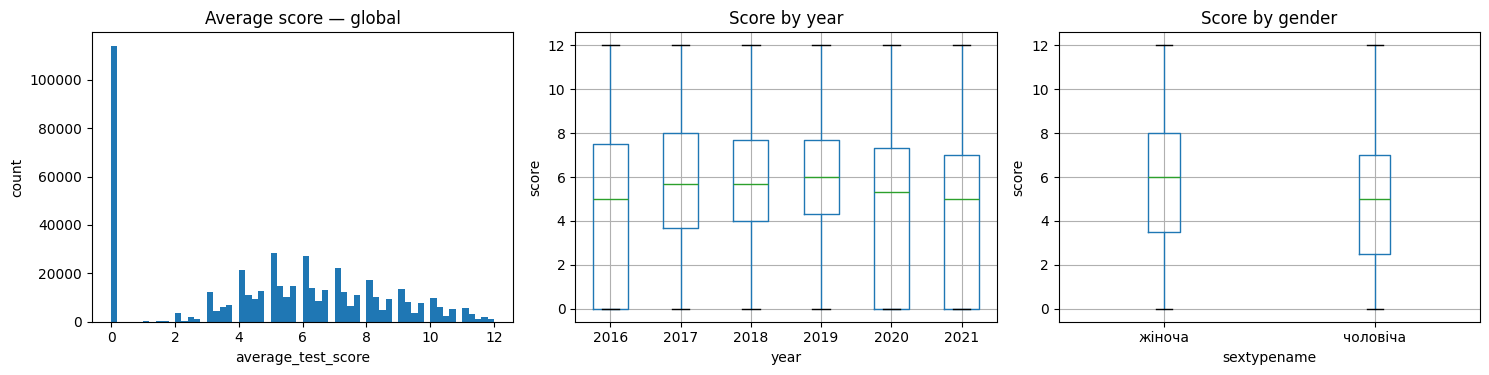

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Global histogram
axs = ax[0]
axs.hist(S["average_test_score"].dropna(), bins=60)
axs.set_title("Average score — global")
axs.set_xlabel("average_test_score"); axs.set_ylabel("count")

# Boxplot by year
axs = ax[1]
S.boxplot(column="average_test_score", by="year", ax=axs)
axs.set_title("Score by year"); axs.set_xlabel("year"); axs.set_ylabel("score")
axs.figure.suptitle("")

# Boxplot by gender
axs = ax[2]
if "sextypename" in S.columns:
    S.boxplot(column="average_test_score", by="sextypename", ax=axs)
    axs.set_title("Score by gender"); axs.set_xlabel("sextypename"); axs.set_ylabel("score")
    axs.figure.suptitle("")
else:
    axs.set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# Settlement & test language quick tables (top categories)
if "tertypename" in data.columns:
    display(top_n_categories(data.dropna(subset=["average_test_score"]), "tertypename", n=5))
if "testlanguage" in data.columns:
    display(top_n_categories(data.dropna(subset=["average_test_score"]), "testlanguage", n=8))


,tertypename,count,pct
0,місто,1404374,71.4
1,"селище, село",422839,21.5
2,unknown,85942,4.37
3,селище міського типу,53859,2.74


,testlanguage,count,pct
0,українська,1726666,87.78
1,unknown,124865,6.35
2,російська,108557,5.52
3,угорська,3970,0.2
4,румунська,2137,0.11
5,молдовська,643,0.03
6,польська,176,0.01


In [25]:
# Cross-tab of settlement type frequencies by year (spot schema drifts)
print(data.pivot_table(index="year", columns="tertypename", values="outid", aggfunc="size", fill_value=0))


tertypename  unknown   місто  селище міського типу  селище, село
year                                                            
2016           85942   74910                 22344         84807
2017               0  173668                     0         67221
2018               0  272278                     0         63409
2019               0  290781                     0         63032
2020               0  308547                     0         70752
2021               0  284190                 31515         73618


,dpa_required_done,took_bio,took_chem,took_deu,took_eng,took_fr,took_geo,took_hist,took_math,took_phys,took_rus,took_sp,took_ukr,took_uml
year,,,,,,,,,,,,,,
2017,79.0,22.9,2.0,0.5,20.6,0.2,16.9,56.9,32.0,5.2,0.6,0.0,0.0,79.2
2018,54.7,15.0,1.2,0.3,15.1,0.1,13.9,38.6,21.9,3.0,0.0,0.0,0.0,89.3
2019,85.0,14.4,1.0,0.2,15.8,0.1,12.8,55.6,34.6,2.9,0.0,0.0,0.0,89.2
2020,63.7,14.1,1.1,0.2,19.0,0.1,16.3,40.8,31.7,3.4,0.0,0.0,0.0,65.5
2021,54.7,16.4,1.3,0.3,28.6,0.1,24.8,45.9,58.8,4.7,0.0,0.0,15.7,51.3


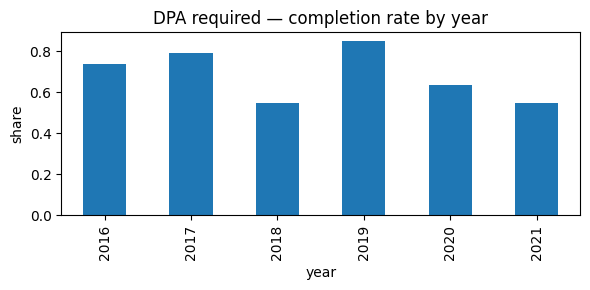

In [26]:
# Participation & DPA completion over time
took_cols = [c for c in data.columns if c.startswith("took_") and not c.endswith("_any")]
cols_to_show = sorted(set(took_cols + ["dpa_required_done"]) & set(data.columns))
if cols_to_show:
    by_year = data.groupby("year")[cols_to_show].mean().sort_index()
    display((by_year * 100).round(1).tail())

    # DPA completion rate bar plot
    if "dpa_required_done" in data.columns:
        share = data.groupby("year")["dpa_required_done"].mean().sort_index()
        share.plot(kind="bar", figsize=(6, 3))
        plt.title("DPA required — completion rate by year")
        plt.ylabel("share")
        plt.tight_layout()
        plt.show()
        

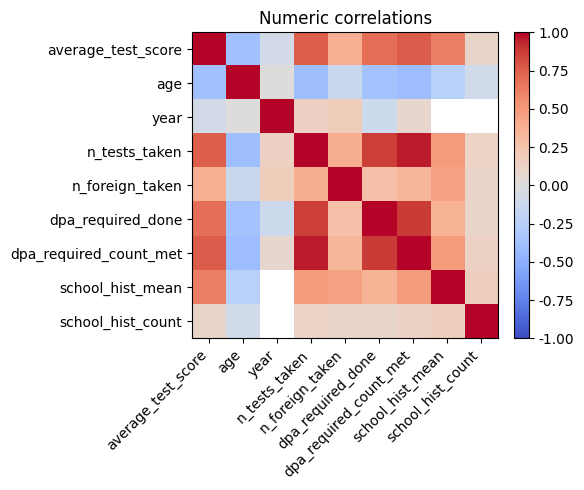

In [27]:
# Correlations among numeric features used for modeling (leakage-safe)
num_corr_cols = [c for c in [
    "average_test_score","age","year",
    "n_tests_taken","n_foreign_taken",
    "dpa_required_done","dpa_required_count_met",
    "school_hist_mean","school_hist_count"
] if c in data.columns]
if num_corr_cols:
    corr = data[num_corr_cols].corr()
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(num_corr_cols))); ax.set_xticklabels(num_corr_cols, rotation=45, ha="right")
    ax.set_yticks(range(len(num_corr_cols))); ax.set_yticklabels(num_corr_cols)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.title("Numeric correlations")
    plt.tight_layout()
    plt.show()
    

In [28]:
# Regions (top-10 by volume): simple descriptive stats
if "regname" in data.columns:
    top_regs = data["regname"].value_counts().head(10).index
    tbl = (data.loc[data["regname"].isin(top_regs)]
             .groupby("regname")["average_test_score"]
             .agg(["count","mean","std"]).sort_values("count", ascending=False))
    display(tbl)
    

,count,mean,std
regname,,,
м.Київ,164466,5.772059,3.647305
Дніпропетровська область,159308,4.874484,3.354794
Львівська область,135733,5.518600,3.579447
Харківська область,123142,5.226914,3.443393
Одеська область,121797,4.863048,3.224672
Запорізька область,85460,4.747995,3.330092
Донецька область,83574,4.855349,3.307715
Вінницька область,83166,4.955354,3.300148
Київська область,81558,5.113761,3.377797


====================== Cell 4: Feature selection (leakage-safe) + temporal split ======================

We construct a feature matrix from year-robust categorical and numeric fields.

We explicitly exclude all score and status columns to avoid label leakage.

Temporal split: train on 2016–2020, test on 2021. If 2021 missing, fall back to random split.

In [29]:
target = "average_test_score"
if data.empty or target not in data.columns:
    X = pd.DataFrame()
    y = pd.Series(dtype=float, name=target)
else:
    # Block any leakage from subject-level outcomes or statuses
    score_cols  = [c for c in data.columns if c.endswith("ball12")]
    status_cols = [c for c in data.columns if "teststatus" in c]
    banned = set(score_cols + status_cols + [target])

    # Candidate features robust across years
    categorical_candidates = [
        "sextypename","regname","areaname","tername","tertypename","regtypename",
        "classprofilename","classlangname","testlanguage",
    ]
    numeric_candidates = [
        "age", "year","n_tests_taken", "n_foreign_taken",
        "dpa_required_done", "dpa_required_count_met",
        "school_hist_mean", "school_hist_count"
    ]

    cat_features = [c for c in categorical_candidates if c in data.columns and c not in banned]
    num_features = [c for c in numeric_candidates if c in data.columns and c not in banned]

    X = data[cat_features + num_features].copy()
    y = data[target].astype(float).copy()

    # Enforce consistent dtype for categoricals (string → OHE later)
    for c in cat_features:
        X[c] = X[c].astype("string")
    print(f"[info] features → cat={len(cat_features)} | num={len(num_features)}")

    # Drop rows with no positive scores at all (often noisy outliers)
    if DROP_ZERO_NOSCORE:
        tst_cols = [c for c in data.columns if c.endswith("teststatus")]
        if tst_cols:
            has_any_score = data[tst_cols].eq("has score").any(axis=1)
            keep = has_any_score & (y > 0)
            dropped = int((~keep).sum())
            X, y = X.loc[keep], y.loc[keep]
            print(f"[filter] dropped {dropped:,} strict no-score rows")

[info] features → cat=9 | num=8
[filter] dropped 446,589 strict no-score rows


In [30]:
# Temporal split if 2021 exists; else, random split for robustness
if not X.empty and "year" in data.columns and (data["year"] == 2021).any():
    m_train = (data.loc[X.index, "year"] < 2021).values
    m_test  = (data.loc[X.index, "year"] == 2021).values
    X_train, y_train = X.loc[m_train], y.loc[m_train]
    X_test,  y_test  = X.loc[m_test],  y.loc[m_test]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    

In [31]:
# Optional groups for GroupKFold audits downstream (by school)
groups_train = data.loc[X_train.index, "eoname"].astype(str) if "eoname" in data.columns else None
groups_test  = data.loc[X_test.index, "eoname"].astype(str)  if "eoname" in data.columns else None
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (1257420, 17) | Test: (263005, 17)


====================== Cell 5: Robust preprocessing (categoricals → OHE, numerics → scaled) ======================

ColumnTransformer with:
  - Numeric pipeline: median imputation + StandardScaler (without centering to support sparse)
  - Categorical pipeline: OneHotEncoder with min_frequency for width control in FAST mode


In [32]:
# Lock feature lists (defensive recomputation)
cat_features = [c for c in ["sextypename","regname","areaname","tername","tertypename",
                            "regtypename","classprofilename","classlangname","testlanguage"]
                if c in X_train.columns]
num_features = [c for c in ["age","year","n_tests_taken","n_foreign_taken",
                            "dpa_required_done","dpa_required_count_met",
                            "school_hist_mean", "school_hist_count"]
                if c in X_train.columns]


In [33]:
# Type hygiene: numerics → numeric dtype
for c in num_features:
    X_train.loc[:, c] = pd.to_numeric(X_train[c], errors="coerce")
    X_test.loc[:,  c] = pd.to_numeric(X_test[c],  errors="coerce")
    

In [34]:
# Categorical NA handling: fill sentinel to avoid pd.NA downstream in OHE
SENTINEL = "__MISSING__"
for df_ in (X_train, X_test):
    for c in cat_features:
        df_.loc[:, c] = df_[c].astype(object)
    df_.loc[:, cat_features] = df_[cat_features].where(
        pd.notna(df_[cat_features]), SENTINEL
    )
    

In [35]:
# Numeric transformer: impute + scale (no mean centering on sparse)
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler(with_mean=False)),
])


In [36]:
# OneHotEncoder compatibility across sklearn versions
enc_sig = signature(OneHotEncoder.__init__)
use_sparse_output = "sparse_output" in enc_sig.parameters
ohe_kwargs = dict(handle_unknown="ignore")
if use_sparse_output:
    ohe_kwargs["sparse_output"] = True
else:
    ohe_kwargs["sparse"] = True
    

In [37]:
# Size control: clip extremely rare categories in FAST mode
min_freq = 0.02 if FAST else 20
if "min_frequency" in enc_sig.parameters:
    ohe_kwargs["min_frequency"] = min_freq
    

In [38]:
# Categorical transformer: OHE only (we already imputed)
categorical_tf = Pipeline([
    ("onehot", OneHotEncoder(**ohe_kwargs)),
])


In [39]:
# ColumnTransformer: join numeric and categorical pipelines
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_features),
        ("cat", categorical_tf, cat_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


In [40]:
# Fit/transform → keep arrays float32, preserve sparse when available
print("[stage] fitting preprocessing ...")
t0 = perf_counter()
Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)
Xtr = (Xtr.tocsr() if sparse.issparse(Xtr) else np.asarray(Xtr)).astype(np.float32)
Xte = (Xte.tocsr() if sparse.issparse(Xte) else np.asarray(Xte)).astype(np.float32)
print(f"[done] preprocessing in {perf_counter()-t0:,.1f}s | "
      f"train {X_train.shape}→{Xtr.shape} | test {X_test.shape}→{Xte.shape}")


[stage] fitting preprocessing ...
[done] preprocessing in 11.2s | train (1257420, 17)→(1257420, 73) | test (263005, 17)→(263005, 73)


In [41]:
# Transformed feature names (best-effort across sklearn versions)
try:
    feat_names_trans = preprocess.get_feature_names_out()
except Exception:
    feat_names_trans = np.array([f"f{i}" for i in range(Xtr.shape[1])])
    

====================== Cell 6: Models + early stopping for XGB + evaluation helpers ======================


In [42]:
def eval_metrics(y_true, y_pred) -> Dict[str, float]:
    """Compute MAE, RMSE, R² for arrays or array-like inputs."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        # For older sklearn versions without squared=
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(rmse),
        "R2": float(r2_score(y_true, y_pred)),
    }
    

In [43]:
def _fit_xgb_compat(est, Xtr, ytr, random_state=RANDOM_STATE):
    """Fit XGBRegressor with broad EarlyStopping compatibility across versions.
    Falls back to plain .fit if callbacks or kwargs are unsupported."""
    Xtr0, Xval, ytr0, yval = train_test_split(Xtr, ytr, test_size=0.10, random_state=random_state)

    tried_kwargs = [
        {"early_stopping_rounds": 50, "eval_set": [(Xval, yval)], "verbose": False},
        {"early_stopping_rounds": 50, "eval_set": [(Xval, yval)]},  # alternative without verbose
        {"callbacks": [XGBEarlyStopping(rounds=50, save_best=True)] if XGBEarlyStopping else None,
         "eval_set": [(Xval, yval)], "verbose": False},
        {"eval_set": [(Xval, yval)], "verbose": False},
        {"eval_set": [(Xval, yval)]},
        {},
    ]

    for kw in tried_kwargs:
        kw = {k: v for k, v in kw.items() if v is not None}
        try:
            est.fit(Xtr0, ytr0, **kw)
            return est
        except TypeError:
            continue

    est.fit(Xtr, ytr)
    return est
    

In [44]:
def fit_and_eval(name: str, est, Xtr, ytr, Xte, yte):
    """Clone, fit, predict, and print metrics for a given estimator.
    Returns (name, metrics_dict, fitted_estimator)."""
    start = perf_counter()
    est = clone(est)

    if "XGBRegressor" in est.__class__.__name__:
        est = _fit_xgb_compat(est, Xtr, ytr, random_state=RANDOM_STATE)
    else:
        est.fit(Xtr, ytr)

    preds = est.predict(Xte)

    try:
        rmse = mean_squared_error(yte, preds, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(yte, preds))

    metrics = {
        "MAE": float(mean_absolute_error(yte, preds)),
        "RMSE": float(rmse),
        "R2": float(r2_score(yte, preds)),
    }
    dur = perf_counter() - start
    print(f"[model] {name:12s} in {dur:,.1f}s | R2={metrics['R2']:.3f}  RMSE={metrics['RMSE']:.3f}")
    return name, metrics, est
    

In [45]:
# ---- Model zoo (FAST-friendly defaults; increase capacity in SLOW mode) ----
models = {
    "dummy_median": DummyRegressor(strategy="median"),
    "rf": RandomForestRegressor(
        n_estimators=150 if FAST else 500,
        max_depth=12 if FAST else 24,
        max_features=0.5 if FAST else 1.0,
        min_samples_leaf=2,
        max_samples=0.5 if FAST else 0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}
if HAS_XGB:
    models["xgb"] = XGBRegressor(
        n_estimators=600 if FAST else 900,
        learning_rate=0.07 if FAST else 0.05,
        max_depth=5 if FAST else 7,
        min_child_weight=3 if FAST else 7,
        subsample=0.8 if FAST else 1,
        colsample_bytree=0.9,
        reg_lambda=1.0 if FAST else 10,
        reg_alpha=0.0,
        tree_method="hist",
        max_bin=256,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        eval_metric="rmse",
        verbosity=0,
    )
    

In [46]:
# ---- Model tuning prep (time-aware CV) ---- 
DO_TUNING = not FAST  # toggle


In [47]:
def tune_model(name, base_estimator, preprocess, X_df, y, random_state=RANDOM_STATE):
    """RandomizedSearchCV wrapper around a Pipeline(preprocess, model) with GroupKFold on 'year'.
    Returns (best_fitted_pipeline, best_params_dict)."""
    pipe = Pipeline([("preprocess", preprocess), ("model", clone(base_estimator))])
    groups = X_df["year"].astype(int) if "year" in X_df.columns else pd.Series(0, index=X_df.index)

    n_iter = 12 if FAST else 35
    cv = GroupKFold(n_splits=3 if FAST else 5)

    if name == "xgb":
        param_distributions = {
            "model__n_estimators": np.linspace(300, 1200, 10, dtype=int),
            "model__max_depth": [4,5,6,7,8],
            "model__learning_rate": loguniform(1e-2, 2e-1),
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0],
            "model__min_child_weight": [1,3,5,7,10],
            "model__reg_lambda": [0.1, 1, 5, 10],
            "model__reg_alpha": [0.0, 0.1, 0.5],
        }
    elif name == "rf":
        param_distributions = {
            "model__n_estimators": np.linspace(200, 800, 7, dtype=int),
            "model__max_depth": [None, 12, 16, 20, 24],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": [0.3, 0.5, 0.7, 1.0],
            "model__max_samples": [0.5, 0.8, None],
        }
    else:
        # Nothing to tune: fit the baseline pipeline directly
        pipe.fit(X_df, y)
        return pipe, {}

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv.split(X_df, y, groups=groups),
        random_state=random_state,
        n_jobs=-1,
        verbose=1 if not FAST else 0,
        refit=True,
    )
    search.fit(X_df, y)
    best_pipe = search.best_estimator_
    print(f"[tune] {name}: best CV RMSE={-search.best_score_:.3f}")
    return best_pipe, search.best_params_
    

====================== Cell 7: Train sequentially, pick best, persist pipeline ======================

Train models on transformed matrices (Xtr, Xte), collect metrics, choose the best by R².

If tuning is enabled, re-fit via GroupKFold(RandomizedSearchCV) and pick the tuned variant.


In [48]:
print("[stage] training models ...")
results = [fit_and_eval(n, m, Xtr, y_train, Xte, y_test) for n, m in models.items()]
print("[done] all models trained.")


[stage] training models ...
[model] dummy_median in 0.0s | R2=-0.012  RMSE=2.190
[model] rf           in 384.7s | R2=0.226  RMSE=1.915
[model] xgb          in 31.8s | R2=0.236  RMSE=1.903
[done] all models trained.


In [49]:
# Aggregate metrics and pick best by R²
metrics_all = {}
best_name, best_r2, best_est = None, -1e9, None
for name, m, est in results:
    metrics_all[name] = m
    if m["R2"] > best_r2:
        best_name, best_r2, best_est = name, m["R2"], est
        

In [50]:
# Build final pipeline (optionally tuned)
final_pipeline = None
best_label = best_name


In [51]:
if DO_TUNING and best_name in ("xgb", "rf"):
    tuned_pipe, tuned_params = tune_model(best_name, models[best_name], clone(preprocess), X_train.copy(), y_train)
    # Evaluate tuned pipeline on raw X_test (preprocess inside the pipeline)
    tuned_pred = tuned_pipe.predict(X_test)
    try:
        tuned_rmse = mean_squared_error(y_test, tuned_pred, squared=False)
    except TypeError:
        tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
    tuned_r2 = r2_score(y_test, tuned_pred)
    print(f"[tuned] {best_name}: Test R2={tuned_r2:.3f} RMSE={tuned_rmse:.3f}")
    if tuned_r2 >= metrics_all[best_name]["R2"]:
        final_pipeline = tuned_pipe
        best_label = f"{best_name}_tuned"
        print("[select] tuned pipeline chosen for artifact.")
    else:
        print("[select] tuned underperforms on holdout; keep untuned.")


In [52]:
# If not tuned or tuned worse, wrap best_est with a fresh preprocessing pipeline
if final_pipeline is None:
    final_pipeline = Pipeline([("preprocess", clone(preprocess)), ("model", clone(best_est))])
    final_pipeline.fit(X_train, y_train)


In [53]:
# Holdout predictions (kept for consistent downstream diagnostics)
y_pred = final_pipeline.predict(X_test)


In [54]:
# Persist metrics and full pipeline artifact
(ARTIFACTS_DIR / "metrics.json").write_text(json.dumps(metrics_all, ensure_ascii=False, indent=2), encoding="utf-8")
dump(final_pipeline, ARTIFACTS_DIR / f"pipeline_{best_label}.joblib")
print(f"[artifact] full pipeline saved to artifacts/pipeline_{best_label}.joblib")


[artifact] full pipeline saved to artifacts/pipeline_xgb.joblib


====================== Cell 8: Residual diagnostics + fairness slices (with 95% CIs) ======================


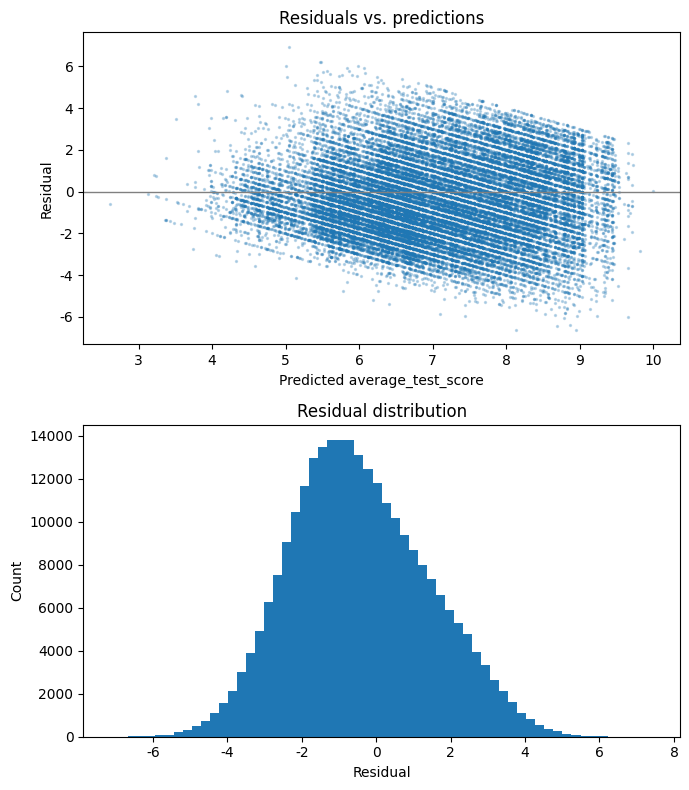

In [55]:
# Residual plots using the final pipeline predictions to ensure consistency with artifacts
if X_test.shape[0] > 0:
    resid = y_test - y_pred
    fig, ax = plt.subplots(2, 1, figsize=(7, 8))
    ax[0].scatter(y_pred[:30_000], resid[:30_000], s=2, alpha=0.25)
    ax[0].axhline(0, color="gray", lw=1)
    ax[0].set_title("Residuals vs. predictions")
    ax[0].set_xlabel("Predicted average_test_score")
    ax[0].set_ylabel("Residual")
    ax[1].hist(resid, bins=60)
    ax[1].set_title("Residual distribution")
    ax[1].set_xlabel("Residual"); ax[1].set_ylabel("Count")
    plt.tight_layout(); plt.savefig(ARTIFACTS_DIR/"residuals.png", dpi=140, bbox_inches="tight"); plt.show()


In [56]:
def _metric_triplet(y_true, y_pred):
    """Helper: return (MAE, RMSE, R²) for a slice."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    err = y_true - y_pred
    mae  = float(np.abs(err).mean())
    rmse = float(np.sqrt((err**2).mean()))
    r2   = float(r2_score(y_true, y_pred))
    return mae, rmse, r2
    

In [57]:
def _bootstrap_cis(y_true, y_pred, B=None, rng=None):
    """Percentile bootstrap confidence intervals for (MAE, RMSE, R²).
    FAST uses B=500; SLOW uses B=2000."""
    if B is None:
        B = 500 if FAST else 2000
    if rng is None:
        rng = np.random.RandomState(RANDOM_STATE)

    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    n = y_true.shape[0]
    idx = np.arange(n)

    maes, rmses, r2s = [], [], []
    for _ in range(B):
        bs = rng.choice(idx, size=n, replace=True)
        m, r, r2 = _metric_triplet(y_true[bs], y_pred[bs])
        maes.append(m); rmses.append(r); r2s.append(r2)

    q = (2.5, 97.5)
    mae_ci  = (float(np.percentile(maes, q[0])),  float(np.percentile(maes, q[1])))
    rmse_ci = (float(np.percentile(rmses, q[0])), float(np.percentile(rmses, q[1])))
    r2_ci   = (float(np.percentile(r2s, q[0])),   float(np.percentile(r2s, q[1])))
    return mae_ci, rmse_ci, r2_ci
    

In [58]:
def fairness_report(y_true, y_pred, data_slice, name):
    """Compute slice-level metrics and 95% bootstrap CIs for categorical group values.
    Slices with n < 50 are skipped to avoid volatile estimates.
    Returns a nested dict: {name: {group_value: {count, MAE, RMSE, R2, *_CI95}}}"""
    s = pd.Series(data_slice).astype("string")
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    out = {}
    for val in s.dropna().unique().tolist():
        mask = s.eq(val).fillna(False).to_numpy()
        n = int(mask.sum())
        if n < 50:
            continue

        yt, yp = y_true[mask], y_pred[mask]
        mae, rmse, r2 = _metric_triplet(yt, yp)
        mae_ci, rmse_ci, r2_ci = _bootstrap_cis(yt, yp)

        out[str(val)] = {
            "count": n,
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "MAE_CI95": mae_ci, "RMSE_CI95": rmse_ci, "R2_CI95": r2_ci,
        }
    return {name: out}


In [59]:
# Build fairness slices across selected demographics and operational flags
fair = {}
if X_test.shape[0] > 0:
    # NOTE: we deliberately reuse y_pred from the final pipeline (Cell 7)
    # to keep artifacts and diagnostics aligned.
    # gender
    if "sextypename" in data.columns:
        fair.update(
            fairness_report(y_test, y_pred, data.loc[X_test.index, "sextypename"], "gender")
        )
    # settlement type
    if "tertypename" in data.columns:
        fair.update(
            fairness_report(y_test, y_pred, data.loc[X_test.index, "tertypename"], "settlement")
        )
    # primary language of testing
    if "testlanguage" in data.columns:
        fair.update(
            fairness_report(y_test, y_pred, data.loc[X_test.index, "testlanguage"], "testlanguage")
        )
    # DPA completion flag (mapped to yes/no)
    if "dpa_required_done" in data.columns:
        dpa_slice = data.loc[X_test.index, "dpa_required_done"].map({0: "no", 1: "yes"}).astype("string")
        fair.update(
            fairness_report(y_test, y_pred, dpa_slice, "dpa_required_done")
        )
    # Regions (top-10 by frequency; others dropped)
    if "regname" in data.columns:
        regs = data.loc[X_test.index, "regname"].astype("string")
        top10 = regs.value_counts().head(10).index
        regs_top = regs.where(regs.isin(top10), other=pd.NA)
        fair.update(
            fairness_report(y_test, y_pred, regs_top, "region_top10")
        )


In [60]:
# Persist fairness report as JSON artifact
(ARTIFACTS_DIR / "fairness_slices.json").write_text(
    json.dumps(fair, ensure_ascii=False, indent=2), encoding="utf-8"
)


7378

In [61]:
# Add MAE gaps versus global holdout MAE (helps spot over/under-performance by group)
global_mae = float(np.abs(y_test - y_pred).mean())
for group, stats in fair.items():
    for k, v in stats.items():
        v["MAE_gap"] = round(v["MAE"] - global_mae, 3)
        

---- Diagnostics (deciles & calibration) ---- 

1) MAE vs true-score deciles,
2) Calibration plot (mean true vs mean predicted by pred deciles),
3) Quick 2021-by-slice summary tables (tertypename, gender, language)

In [62]:
diag = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred})
diag["true_decile"] = pd.qcut(diag["y_true"], q=10, labels=False, duplicates="drop")
diag["pred_decile"] = pd.qcut(diag["y_pred"], q=10, labels=False, duplicates="drop")
diag["abs_err"] = np.abs(diag["y_true"] - diag["y_pred"])


In [63]:
# Error vs true deciles
by_true = diag.groupby("true_decile").agg(
    y_true_mean=("y_true","mean"),
    mae=("abs_err","mean"),
    rmse=("abs_err", lambda s: float(np.sqrt(((diag.loc[s.index, 'y_true'] - diag.loc[s.index, 'y_pred'])**2).mean())))
).reset_index()


In [64]:
# Calibration: ideal line ~ y_true_mean ≈ y_pred_mean per predicted decile
by_pred = diag.groupby("pred_decile").agg(
    y_true_mean=("y_true","mean"),
    y_pred_mean=("y_pred","mean"),
).reset_index()


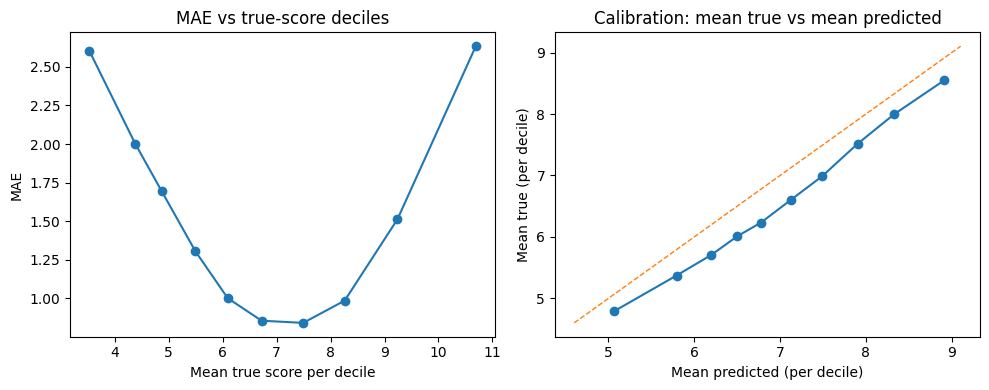

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(by_true["y_true_mean"], by_true["mae"], marker="o")
ax[0].set_title("MAE vs true-score deciles")
ax[0].set_xlabel("Mean true score per decile"); ax[0].set_ylabel("MAE")

ax[1].plot(by_pred["y_pred_mean"], by_pred["y_true_mean"], marker="o")
lims = [min(ax[1].get_xlim()+ax[1].get_ylim()), max(ax[1].get_xlim()+ax[1].get_ylim())]
ax[1].plot(lims, lims, "--", lw=1)  # ideal line
ax[1].set_title("Calibration: mean true vs mean predicted")
ax[1].set_xlabel("Mean predicted (per decile)"); ax[1].set_ylabel("Mean true (per decile)")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR/"diagnostics_deciles_calibration.png", dpi=140, bbox_inches="tight")
plt.show()


In [66]:
# 2021-by-slice quick tables (examples)
if {"tertypename","sextypename"}.issubset(data.columns):
    test_idx = X_test.index
    slices = {}
    for col in ["tertypename","sextypename","testlanguage"]:
        g = data.loc[test_idx, col].astype("string")
        rows = []
        for v, mask in g.groupby(g):
            m = mask.index
            yt = y_test.loc[m].values; yp = pd.Series(y_pred, index=y_test.index).loc[m].values
            mae, rmse, r2 = _metric_triplet(yt, yp)
            rows.append((str(v), len(m), mae, rmse, r2))
        slices[col] = (pd.DataFrame(rows, columns=[col,"count","MAE","RMSE","R2"])
                         .sort_values("count", ascending=False))
        display(slices[col])
        

,tertypename,count,MAE,RMSE,R2
0,місто,197469,1.582237,1.924157,0.246382
2,"селище, село",45059,1.466675,1.802232,0.111693
1,селище міського типу,20477,1.565566,1.905877,0.141340


,sextypename,count,MAE,RMSE,R2
0,жіноча,135980,1.592655,1.931033,0.203913
1,чоловіча,127025,1.527404,1.871243,0.239251


,testlanguage,count,MAE,RMSE,R2
1,українська,262961,1.561143,1.902413,0.235849
0,російська,44,1.546330,1.763760,-0.440929


====================== Cell 9: GroupKFold audit by school ======================

Evaluate stability with GroupKFold on training years using school ('eoname') as groups.

This is an audit, not used for model selection.


In [67]:
def group_cv_r2(estimator, X, y, groups, n_splits=5):
    """Compute mean, std, and fold-level R² across GroupKFold splits."""
    uniq = np.unique(groups)
    if len(uniq) < n_splits:
        raise ValueError(f"Not enough groups for GroupKFold: groups={len(uniq)}, splits={n_splits}")
    gkf = GroupKFold(n_splits=n_splits)
    scores = []
    for tr, va in gkf.split(X, y, groups):
        m = clone(estimator)
        m.fit(X[tr], y.iloc[tr])
        p = m.predict(X[va])
        scores.append(r2_score(y.iloc[va], p))
    scores = np.asarray(scores)
    return scores.mean(), scores.std(ddof=1), scores


In [68]:
try:
    if groups_train is not None:
        # Use the best model if available; otherwise a simple Ridge fallback
        est_for_audit = best_est if best_est is not None else Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(Xtr, y_train)
        mean_r2, std_r2, fold_r2 = group_cv_r2(est_for_audit, Xtr, y_train, groups_train.values,
                                               n_splits=3 if FAST else 5)
        print(f"[GroupKFold by eoname] R2 mean±sd: {mean_r2:.3f} ± {std_r2:.3f} | folds={np.round(fold_r2, 3)}")
    else:
        print("No group column (eoname) available — skipping GroupKFold.")
except ValueError as e:
    print(f"GroupKFold skipped: {e}")
    

[GroupKFold by eoname] R2 mean±sd: 0.332 ± 0.006 | folds=[0.326 0.333 0.338]


====================== Cell 10: Feature importance ======================

Strategy:
 1) If XGB won → use native gain-based feature importance (fast, high-SNR).
 2) Else → grouped permutation importance on a dense sample of transformed features.

In [69]:
def families_from_feature_names(names: np.ndarray) -> dict[str, list[int]]:
    """Group one-hot encoded columns into families by base field, e.g.:
    'sextypename_<cat1>', 'sextypename_<cat2>' → 'sextypename': [idx1, idx2]."""
    fam2idx: dict[str, list[int]] = {}
    for j, full in enumerate(names):
        base = str(full)
        # With verbose_feature_names_out=False, ColumnTransformer yields 'num__age' or 'sextypename_<cat>'
        if "__" in base:
            base = base.split("__", 1)[1]
        base = base.split("_", 1)[0]  # 'sextypename_<cat>' → 'sextypename'
        fam2idx.setdefault(base, []).append(j)
    return fam2idx


In [70]:
def grouped_perm_importance(estimator, X, y, names, n_repeats=5, random_state=RANDOM_STATE, max_n=20000):
    """Permutation importance that shuffles feature families together to respect one-hot structure.
    Returns (importance_df, n_used, n_repeats)."""
    rng = np.random.RandomState(random_state)
    # Sample for tractability on large matrices
    n = min(max_n, X.shape[0])
    idx = rng.choice(X.shape[0], size=n, replace=False)
    Xs = X[idx]
    ys = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
    # Force dense to satisfy permutation_importance contracts across sklearn versions
    Xd = Xs.toarray().astype(np.float32) if sparse.issparse(Xs) else np.asarray(Xs, dtype=np.float32)

    fam2idx = families_from_feature_names(names)
    baseline = mean_absolute_error(ys, estimator.predict(Xd))
    rows = []
    for fam, cols in fam2idx.items():
        deltas = []
        for _ in range(n_repeats):
            perm = rng.permutation(n)
            Xp = Xd.copy()
            Xp[:, cols] = Xd[perm][:, cols]
            mae = mean_absolute_error(ys, estimator.predict(Xp))
            deltas.append(mae - baseline)
        deltas = np.asarray(deltas, float)
        rows.append((fam, float(deltas.mean()), float(deltas.std(ddof=1))))
    imp = (pd.DataFrame(rows, columns=["family", "importance_mean", "importance_std"])
             .sort_values("importance_mean", ascending=False)
             .reset_index(drop=True))
    return imp, n, n_repeats
    

In [71]:
# 1) XGB native importance (if applicable)
imp_df = None
source = None
if best_name == "xgb":
    try:
        booster = best_est.get_booster()
        gain_map = booster.get_score(importance_type="gain")  # {feature_name: gain}
        # XGBoost names features as f0, f1, ... — map to transformed feature names
        mapped = []
        for k, v in gain_map.items():
            try:
                idx = int(k[1:])  # 'f123' → 123
            except Exception:
                continue
            if 0 <= idx < len(feat_names_trans):
                mapped.append((feat_names_trans[idx], float(v)))
        imp_df = (pd.DataFrame(mapped, columns=["feature", "importance"])
                    .sort_values("importance", ascending=False)
                    .reset_index(drop=True))
        source = "xgboost-gain"
    except Exception as e:
        print(f"XGB importance failed ({e}) — falling back to permutation.")
    

In [72]:
# 2) Fallback: grouped permutation importance on transformed features
if imp_df is None:
    imp_df, n_used, n_repeats = grouped_perm_importance(
        best_est, Xte, y_test, feat_names_trans,
        n_repeats=5 if FAST else 10,
        random_state=RANDOM_STATE,
        max_n=15000 if FAST else 30000
    )
    imp_df.rename(columns={"family": "feature", "importance_mean": "importance"}, inplace=True)
    source = "grouped-permutation"

In [73]:
print(f"[importance] source = {source}")
display(imp_df.head(20))


[importance] source = xgboost-gain


,feature,importance
0,regtypename_Учень (слухач) закладу професійної...,11742.187500
1,n_foreign_taken,3375.284912
2,"tertypename_селище, село",2608.831787
3,regtypename_Студент закладу вищої освіти,1937.214844
4,sextypename_жіноча,875.899048
5,areaname_м.Київ,861.220459
6,classprofilename_Математичний,827.449097
7,sextypename_чоловіча,678.377075
8,classprofilename_Іноземної філології,656.288757
9,regname_Закарпатська область,643.961121


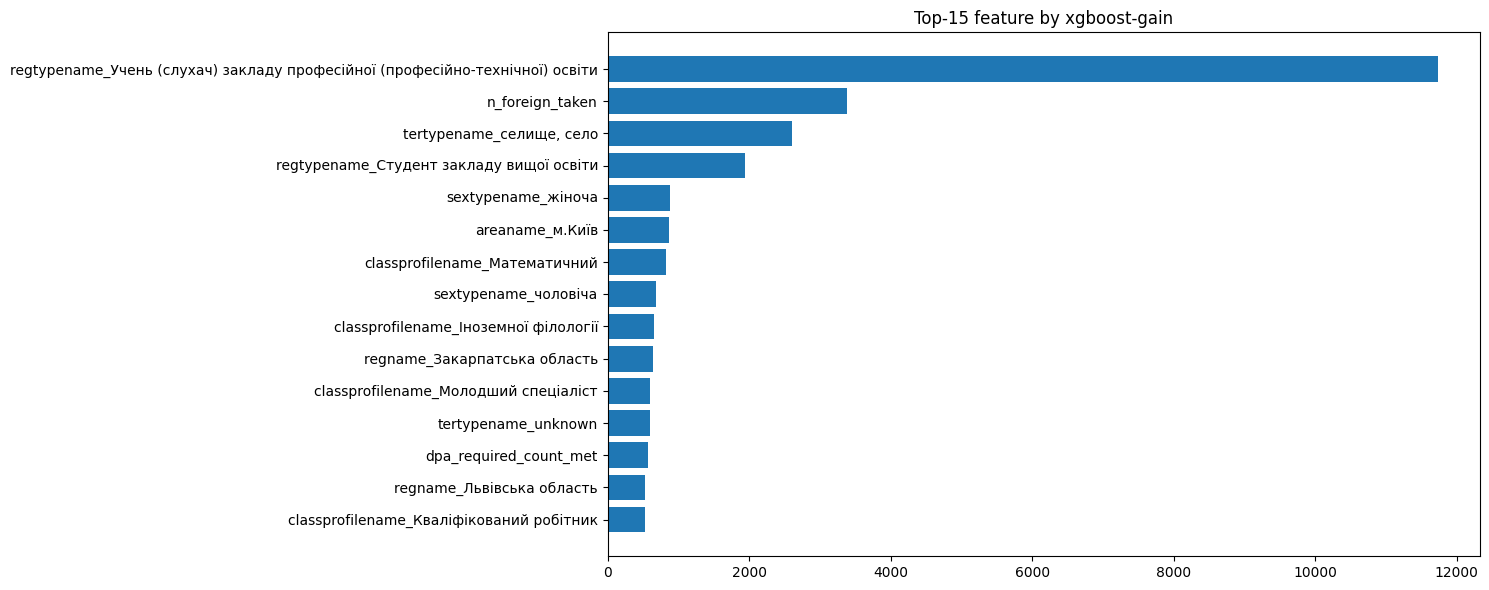

In [74]:
# Save CSV and plot top-15 for reporting
imp_file = ARTIFACTS_DIR / ("feature_importance_top.csv" if source == "xgboost-gain"
                             else "feature_importance_families_grouped.csv")
imp_df.to_csv(imp_file, index=False, encoding="utf-8")
top = imp_df.head(15).iloc[::-1]
plt.figure(figsize=(15, 6))
plt.barh(top["feature"], top["importance"])
plt.title(f"Top-15 feature{' families' if source!='xgboost-gain' else ''} by {source}")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / ("feature_importance_top15.png" if source == "xgboost-gain"
                              else "feature_importance_families_grouped_top15.png"),
            dpi=140, bbox_inches="tight")
plt.show()

====================== Cell 11: Final summary block ======================

Summarize run context, features, metrics, and artifact file paths for reproducibility.


In [75]:
summary = {
    "data_shape": tuple(data.shape) if hasattr(data, "shape") else None,
    "train_shape": tuple(X_train.shape),
    "test_shape": tuple(X_test.shape),
    "features": {"categorical": cat_features, "numeric": num_features},
    "metrics": metrics_all,
    "best_model": best_name,
    "artifacts": {
        "metrics": str((ARTIFACTS_DIR / "metrics.json").resolve()),
        "pipeline": str((ARTIFACTS_DIR / f"pipeline_{best_label}.joblib").resolve()),
        "residuals_png": str((ARTIFACTS_DIR / "residuals.png").resolve()),
        "importance_csv": str((ARTIFACTS_DIR / ("feature_importance_top.csv"
                                                if best_name == "xgb"
                                                else "feature_importance_families_grouped.csv")).resolve()),
    },
}
print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "data_shape": [
    1967014,
    181
  ],
  "train_shape": [
    1257420,
    17
  ],
  "test_shape": [
    263005,
    17
  ],
  "features": {
    "categorical": [
      "sextypename",
      "regname",
      "areaname",
      "tername",
      "tertypename",
      "regtypename",
      "classprofilename",
      "classlangname",
      "testlanguage"
    ],
    "numeric": [
      "age",
      "year",
      "n_tests_taken",
      "n_foreign_taken",
      "dpa_required_done",
      "dpa_required_count_met",
      "school_hist_mean",
      "school_hist_count"
    ]
  },
  "metrics": {
    "dummy_median": {
      "MAE": 1.7946566288346861,
      "RMSE": 2.189942725028502,
      "R2": -0.012353635105459393
    },
    "rf": {
      "MAE": 1.5728056378188613,
      "RMSE": 1.9152089130096974,
      "R2": 0.22571821640815648
    },
    "xgb": {
      "MAE": 1.561637379053856,
      "RMSE": 1.9028567938161614,
      "R2": 0.23567345344875446
    }
  },
  "best_model": "xgb",
  "artifacts": {
 